In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random
import copy
# initialize the codespace with only A-stabilizer 

def lattice_space(H, L):
    lattice = np.zeros((H, L))
    for i in range(H):
        for j in range(L):
            if i % 3 == 0 and j % 3 != 0:
                lattice[i][j] = 1
            if i % 3 == 1 and j % 3 != 2:
                lattice[i][j] = 1
            if i % 3 == 2 and j % 3 != 1:
                lattice[i][j] = 1
    return lattice
import random

def energy(lattice):
    
    H = lattice.shape[0]
    L = lattice.shape[1]
    energy = 0
    for i in range(H):
        for j in range(L):
            # Periodic boundary conditions
            right = lattice[(i+1)% H, (j+1) % L]
            down  = lattice[(i+1) % H, j]
            energy +=  (lattice[i, j] + right + down)% 2
    return energy

def compute_dE(lattice_, i, j):
    # Sum over four neighbors with periodic boundaries
    lattice = copy.deepcopy(lattice_)
    H = lattice.shape[0]
    L = lattice.shape[1]
    s = lattice[i, j]
    ds = (s+1)%2
    left = lattice[i, (j-1)%L] + lattice[(i-1)%H, (j-1)%L]
    right = lattice[(i-1)%H, j] + lattice[i, (j+1)%L]
    bottom = lattice[(i+1)%H, j] + lattice[(i+1)%H, (j+1)%L]
    E  = (left+s)%2 + (right+s)%2 + (bottom+s)%2
    E_new = (left+ds)%2 + (right+ds)%2 + (bottom+ds)%2
    dE = (E_new - E)
    if dE == 0:
        raise ValueError("No change in energy")
    return dE

def monte_carlo_error(lattice, num_steps, error_rate):
    H = lattice.shape[0]
    L = lattice.shape[1]
    for _ in range(num_steps):
        # i = random.randint(0, H - 1)
        # j = random.randint(0, L - 1)
        # r = random.random()
        # if r < error_rate:
        #     # Flip the qubit
        #     lattice[i, j] = (lattice[i, j] + 1) % 2
            
        for i in range(H):
            for j in range(L):
                r = random.random()
                if r < error_rate:
                    # Flip the qubit
                    lattice[i, j] = (lattice[i, j] + 1) % 2
            

    return lattice
    
def nonzero_random():
    r = random.random()
    while r == 0.0:
        r = random.random()
    return r

def bkl(lattice, steps, error_rate, energy_hist= None, time_list= None, spin_list= None, nw = None, sw= None, correction = True, debug = False, config= True):
    
    if energy_hist is None: energy_hist = []
    if time_list   is None: time_list   = []
    if spin_list   is None: spin_list   = []
    if nw          is None: nw          = []
    if sw          is None: sw          = []

    configs     = []
    total_R = []
    f = 1e-8
    beta = math.log((3+error_rate)/error_rate)/3
    H = lattice.shape[0]
    L = lattice.shape[1]
    # mag_list =[]
    spin_class_check = []
    for step in range(steps):

        # Create a dictionary to group spin flips by their energy change (dE)
        classes = {-3:[], -1:[], 1:[], 3:[]}
        # For each spin, compute its energy change upon flipping
        for i in range(H):
            for j in range(L):
                dE = compute_dE(lattice, i, j)
                if dE == -3:
                    classes[-3].append((i, j))
                elif dE == -1:
                    classes[-1].append((i, j))
                elif dE == 1:
                    classes[ 1].append((i, j))
                elif dE == 3:
                    classes[ 3].append((i, j))
                # classes[dE].append((i, j))
        row = np.array([len(classes.get(-3, [])), len(classes.get(-1, [])), len(classes.get( 1, [])), len(classes.get( 3, []))])
        # for dE in (-3, -1, 1, 3):
        #     classes.setdefault(dE, [])
        spin_class_check.append(copy.deepcopy(classes))
        nw.append(row)
        # Calculate transition rates for each class:
        # For spins where flipping lowers energy (dE <= 0), acceptance probability is 1;
        # for dE > 0, it is dE*(1-exp(-beta * dE))
        rates = {}
        total_rate = 0.0
        for dE in sorted(classes):
            if correction == True:
                rate = len(classes[dE])* (dE / (np.exp(beta * dE)-1 ) ) # - error_rate)
            else:
                rate = error_rate
            rates[dE] = rate
            total_rate += rate
        if total_rate == 0:
            print(len(classes), "total_rate is 0")
            continue
        rate_row = np.array([rates.get(-3, 0.0), rates.get(-1, 0.0), rates.get(1, 0.0), rates.get(3, 0.0)])
        sw.append(rate_row)
        # rate_list = []
        # rate_list.append(total_rate)
        # Choose a class according to the rates (weighted selection)
        r = np.random.uniform(0, total_rate)
        cumulative = 0.0
        chosen_class = None
        for dE in sorted(rates):
            cumulative += rates[dE]
            if r <= cumulative :
                # print("hi")
                chosen_class = dE
                break
        if total_rate == 0.0:
            raise ValueError("Total rate is zero, cannot choose a class.")
        spin_list.append(chosen_class)   
        
        configs.append(copy.deepcopy(lattice))
        energy_hist.append(energy(lattice))
        
        if len(classes[chosen_class]) == 0 or chosen_class not in classes: 
            raise ValueError("Chosen class has no spins to flip.")
        
        E_prev = energy(lattice)
        # From the chosen class, select a spin uniformly at random
        i, j = random.choice(classes[chosen_class]) 
        # Flip the spin
        lattice[i, j] = (lattice[i, j] + 1) % 2 
        E_new = energy(lattice)

    # ============= spin flip check ==========
        check = np.zeros((H,L))
        check[i,j] = 1
        if len(configs)>0 and not np.array_equal(((lattice + check) % 2) , configs[-1] ) :
            print('i,j', i, j)
            print('current config\n', lattice)
           
            print('last config\n', configs[-1])
            print('step', step)
            raise ValueError('Spin not flipped correctly')
        

    # ============= energy check ==========
        if E_new != E_prev + chosen_class:
            print('current energy', energy_hist[-1] )
            print('dE', chosen_class)
            print('last enregy', energy_hist[-2])
            print('spin config\n', lattice)
            print('i,j', i, j)
            print('step', len(energy_hist))
            print('energ list', energy_hist)
            print('rate', rates)
            print('previsou config\n', configs[-2])
            print('current config\n', configs[-1])
            print('before before config\n', configs[-3])
            raise ValueError('Energy not consistent')  
         
    # ============= rate check ============  
        # if len(rate)


        rho3 = nonzero_random()
        dT = 1/total_rate * -math.log(rho3)

        total_R.append(total_rate)
        
        time_list.append(dT)
        # mag_list.append(np.sum(lattice) / (H * L))
    if debug:
        return lattice, beta, rates
    elif config:
        return lattice, energy_hist, time_list, np.array(configs), np.array(total_R), spin_class_check
    else:
        return lattice

def time_bin(time_lists:list):
    """
    Bins the time lists into intervals of size bin_size.
    Returns a list of binned times and their corresponding counts.
    """
    # flatten cumsum lists in one and divide by equllength bins
    flattened = time_lists.copy().ravel()
    order = np.argsort(np.abs(flattened))
    flat_sorted_by_mag = flattened[order]
    nbins = np.array(time_lists).shape[1]
    edges = np.linspace(flat_sorted_by_mag.min(), flat_sorted_by_mag.max(), nbins+1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    # create bins 
    bin_idx = np.digitize(flat_sorted_by_mag, edges) - 1
    bin_idx = np.clip(bin_idx, 0, nbins-1)

    sums   = np.bincount(bin_idx, weights=flat_sorted_by_mag, minlength=nbins)
    counts = np.bincount(bin_idx,           minlength=nbins)

    means = np.empty_like(centers)
    # normal division where counts>0
    np.divide(sums, counts, out=means, where=(counts>0))
    # fill empty bins with the bin center
    empty = (counts == 0)
    means[empty] = centers[empty]
    return means

def _step_fill_uniform_1d(times, values, dt=None, n_steps=None,
                          include_start=True, include_end=False):
    """
    Resample a step function defined by (times, values) onto a uniform grid
    using left-hold (previous value) semantics.

    Parameters
    ----------
    times : 1D array-like, strictly increasing
    values: 1D array-like, same length as `times`
    dt : float, optional
        Target uniform step in physical time. If None, inferred from n_steps.
    n_steps : int, optional
        Number of uniform steps between times[0] and times[-1].
        If provided, dt=(t_end - t_start)/n_steps.
    include_start : bool, default True
        Include the initial time t0 in the output grid.
    include_end : bool, default False
        Include the final time t_end in the output grid.

    Returns
    -------
    t_out, v_out : 1D ndarray
        Uniform grid times and left-hold values.
    """
    t = np.asarray(times, dtype=float)
    v = np.asarray(values, dtype=float)
    if t.ndim != 1 or v.ndim != 1 or len(t) != len(v) or len(t) < 2:
        raise ValueError("times/values must be 1D, same length >=2")
    if not np.all(np.diff(t) > 0):
        raise ValueError("times must be strictly increasing")

    t0, t1 = t[0], t[-1]
    span = t1 - t0
    if span <= 0:
        # Degenerate: all times equal – just return a single sample
        return (np.array([t0]) if include_start else np.array([]),
                np.array([v[0]]) if include_start else np.array([]))

    if dt is None and n_steps is None:
        raise ValueError("Specify either dt or n_steps")
    if dt is None:
        if n_steps <= 0:
            raise ValueError("n_steps must be positive")
        dt = span / n_steps

    # Build the uniform grid
    eps = np.finfo(float).eps * max(1.0, abs(t1))
    start = t0 if include_start else (t0 + dt)
    stop  = (t1 + (eps if include_end else 0.0))
    if start > stop + 1e-15:
        # Nothing to sample
        return np.array([], dtype=float), np.array([], dtype=float)
    t_grid = np.arange(start, stop, dt)
    if include_end and (t_grid.size == 0 or t_grid[-1] < t1 - 0.5*dt):
        # Ensure exact inclusion if requested (avoid FP drift)
        t_grid = np.r_[t_grid, t1]

    # Left-hold: for each grid point τ, pick index i with t[i] <= τ < t[i+1]
    idx = np.searchsorted(t, t_grid, side='right') - 1
    # Clamp to valid range (could be -1 if τ < t0 due to numerical noise)
    idx = np.clip(idx, 0, len(t) - 1)
    v_grid = v[idx]
    return t_grid, v_grid


def step_fill_uniform(times, mags, dt=None, n_steps=None,
                      include_start=False, include_end=False, per_seed=True):
    """
    Batch wrapper. Accepts:
      - a single (times, mags) 1D pair, or
      - lists/arrays of per-realization times and mags (ragged allowed).

    If you pass multiple realizations:
      * If dt is given, that same dt is used for every realization.
      * If n_steps is given and dt is None:
          - per_seed=True  → use each seed's own (t_end - t_start)/n_steps
          - per_seed=False → compute a global dt from the *first* seed's span
                             (or you can change to use global min/max if you prefer).

    Returns
    -------
    T_out, M_out :
        If single trace → (1D t_out, 1D m_out).
        If batch        → (list of 1D arrays t_out_i, list of 1D arrays m_out_i).
    """
    # Detect single vs batch
    def _is_1d_like(x):
        return np.ndim(x) == 1

    # Single trace
    if _is_1d_like(times) and _is_1d_like(mags):
        return _step_fill_uniform_1d(times, mags, dt=dt, n_steps=n_steps,
                                     include_start=include_start, include_end=include_end)

    # Batch: each element of times/mags is a 1D array-like for one realization
    if len(times) != len(mags):
        raise ValueError("For batch input, lengths of times and mags lists must match")

    # Resolve dt per seed if needed
    if dt is not None:
        dts = [float(dt)] * len(times)
    else:
        if n_steps is None:
            raise ValueError("For batch input, specify dt or n_steps")
        if per_seed:
            dts = []
            for ti in times:
                ti = np.asarray(ti, dtype=float)
                if ti.size < 2:
                    raise ValueError("Each seed must have at least 2 timestamps")
                dts.append((ti[-1] - ti[0]) / n_steps)
        else:
            t0 = np.asarray(times[0], dtype=float)
            base_dt = (t0[-1] - t0[0]) / n_steps
            dts = [base_dt] * len(times)

    T_out, M_out = [], []
    for ti, mi, dti in zip(times, mags, dts):
        t_i, m_i = _step_fill_uniform_1d(ti, mi, dt=dti, n_steps=None,
                                         include_start=include_start, include_end=include_end)
        T_out.append(t_i)
        M_out.append(m_i)
    return T_out, M_out


def time_bin(time_lists:list, decoder_mag:list):
    """
    Bins the time lists into intervals of size bin_size.
    Returns a list of binned times and their corresponding counts.
    """
    # flatten cumsum lists in one and divide by equllength bins
    flattened_time = np.concatenate(time_lists)
    flattened_mag = np.concatenate(decoder_mag)

    order_time = np.argsort(np.abs(flattened_time))
    flat_sorted_by_mag_time = flattened_time[order_time]
    flat_sorted_by_mag_mag = flattened_mag[order_time]

    nbins = np.array(time_lists).shape[1]
    edges_time = np.linspace(flat_sorted_by_mag_time.min(), flat_sorted_by_mag_time.max(), nbins+1)
    centers_time = 0.5 * (edges_time[:-1] + edges_time[1:])

    edges_mag = np.linspace(flat_sorted_by_mag_mag.min(), flat_sorted_by_mag_mag.max(), nbins+1)
    centers_mag = 0.5 * (edges_mag[:-1] + edges_mag[1:])

    # create bins 
    bin_idx_1 = np.digitize(flat_sorted_by_mag_time, edges_time) - 1
    bin_idx_1 = np.clip(bin_idx_1, 0, nbins-1)

    sums_time   = np.bincount(bin_idx_1, weights=flat_sorted_by_mag_time, minlength=nbins)
    counts_time = np.bincount(bin_idx_1,           minlength=nbins)

    sums_mag   = np.bincount(bin_idx_1, weights=flat_sorted_by_mag_mag, minlength=nbins)
    counts_mag = np.bincount(bin_idx_1,           minlength=nbins)

    means_time = np.empty_like(centers_time)
    means_mag = np.empty_like(centers_mag)
    # normal division where counts>0
    np.divide(sums_time, counts_time, out=means_time, where=(counts_time>0))
    np.divide(sums_mag, counts_mag, out=means_mag, where=(counts_mag>0))
    # fill empty bins with the bin center
    valid = counts_time > 0
    empty = ~valid
    means_time[empty] = centers_time[empty]

    means_mag[empty]    = np.interp(centers_time[empty],
                                    centers_time[valid], means_mag[valid])
    return means_time,  means_mag


def time_bin_1(time_lists:list, decoder_mag:list):
    """
    Bins the time lists into intervals of size bin_size.
    Returns a list of binned times and their corresponding counts.
    """
    # flatten cumsum lists in one and divide by equllength bins
    N, T = np.array(time_lists).shape
    time_finer = np.zeros((N, (T-1)*10))
    mag_finer = np.zeros((N, (T-1)*10))
    min_t = min([min(np.diff(tl)) for tl in time_lists])
    # for i in range(N):
    #     time_finer[i], mag_finer[i] = step_fill_uniform(time_lists[i], decoder_mag[i], n_steps=(T-1)*10)
    time_finer, mag_finer = step_fill_uniform(time_lists, decoder_mag, n_steps=(T-1)*30)
    flattened_time = np.concatenate(time_finer)
    flattened_mag = np.concatenate(mag_finer)

    order_time = np.argsort(np.abs(flattened_time))
    flat_sorted_by_mag_time = flattened_time[order_time]
    flat_sorted_by_mag_mag = flattened_mag[order_time]

    nbins = np.array(time_lists).shape[1]
    edges_time = np.linspace(flat_sorted_by_mag_time.min(), flat_sorted_by_mag_time.max(), nbins+1)
    centers_time = 0.5 * (edges_time[:-1] + edges_time[1:])

    edges_mag = np.linspace(flat_sorted_by_mag_mag.min(), flat_sorted_by_mag_mag.max(), nbins+1)
    centers_mag = 0.5 * (edges_mag[:-1] + edges_mag[1:])

    # create bins 
    bin_idx_1 = np.digitize(flat_sorted_by_mag_time, edges_time) - 1
    bin_idx_1 = np.clip(bin_idx_1, 0, nbins-1)

    sums_time   = np.bincount(bin_idx_1, weights=flat_sorted_by_mag_time, minlength=nbins)
    counts_time = np.bincount(bin_idx_1,           minlength=nbins)

    sums_mag   = np.bincount(bin_idx_1, weights=flat_sorted_by_mag_mag, minlength=nbins)
    counts_mag = np.bincount(bin_idx_1,           minlength=nbins)

    means_time = np.empty_like(centers_time)
    means_mag = np.empty_like(centers_mag)
    # normal division where counts>0
    np.divide(sums_time, counts_time, out=means_time, where=(counts_time>0))
    np.divide(sums_mag, counts_mag, out=means_mag, where=(counts_mag>0))
    # fill empty bins with the bin center
    valid = counts_time > 0
    empty = ~valid
    means_time[empty] = centers_time[empty]

    means_mag[empty]    = np.interp(centers_time[empty],
                                    centers_time[valid], means_mag[valid])
    return means_time,  means_mag



In [3]:
# optimal decoder
import numpy as np

def syndrome_detector(lattice):
    """
    Detects errors in syndrom measuring A-stabilizer
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    errors = np.zeros((H,L), dtype=int)
    #errors = np.zeros((H,L))
    for i in range(H):
        for j in range(L):
            if (lattice[i, j]+lattice[(i+1) %H, j]+lattice[(i+1)%H, (j+1)%L]) % 2 != 0:  # error by A-stablizer
                #errors[i][j]= 1
                errors[i][j] = 1  
    return errors

def error_qubit_detector(lattice):
    """
    Detects errors in the lattice and returns a list of qubits to be flipped.
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    errors = syndrome_detector(lattice)
    error_qubits = np.zeros((H,L),dtype=int)
    for i in range(H):
        for j in range(L):
            if not (errors[i][j] or errors[(i-1)%H][j] or errors[(i-1)%H][(j-1)%L]):  
                error_qubits[i][j]= 1   # Assuming 1 indicates an error
    return error_qubits

def sweeper_test(lattice):
    """
    Sweeps through the lattice and move the defects. to the first row.
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    errors = np.zeros((H,L))
    latt = lattice.copy()
    for i in range(H-1):      # to H or H-1?/
        for j in range(L):
            if (latt[(H-i-1)%H, j]+latt[(H-i)%H, j]+latt[(H-i)%H, (j+1)%L]) % 2 == 1:  # error by A-stablizer
                errors[(H-i-1)%H][j]= 1
                latt[(H-i-1)% H][j] = (latt[(H-i-1) % H][j] + 1) % 2 
    return latt, errors
def sweeper(lattice):
    H = lattice.shape[0]
    L = lattice.shape[1]
    errors = np.zeros((H,L), dtype=int)
    latt = lattice.copy()
    for i in range(H-1):      # to H or H-1?/
        for j in range(L):
            if latt[(H-i-1)%H, j] == 1:
                errors[(H-i-1)%H][j]= 1
                latt[(H-i-1)% H][j] = (latt[(H-i-1) % H][j] + 1) % 2
                latt[(H-i-2)% H][j] = (latt[(H-i-2) % H][j] + 1) % 2
                latt[(H-i-2)% H][(j-1) % L] = (latt[(H-i-2) % H][(j-1) % L] + 1) % 2
    return latt, errors


def update_rule(lattice):
    """
    Update rule 102, input row_i+1, returns row_i
    """
    # H = lattice.shape[0]
    L = lattice.shape[1]
    f = np.eye(L,dtype=int)
    f += cyclic_shift(L)  # cyclic shift matrix
    # for j in range(L):
    #     for i in range(L):
    #         if j % 3 ==0 and i % 3 == 0:
    #             f[j][i] = 1
    #         if j % 3 == 0 and i % 3 == 1:
    #             f[j][i] = 1
    #         if j % 3 == 1 and i % 3 == 1:
    #             f[j][i] = 1
    #         if j % 3 == 1 and i % 3 == 2:
    #             f[j][i] = 1
    #         if j % 3 == 2 and i % 3 == 0:
    #             f[j][i] = 1
    #         if j % 3 == 2 and i % 3 == 2:
    #             f[j][i] = 1
    
    return f

def cyclic_shift(L):
    """
    Return the L×L matrix P which, when you do P @ v,
    cyclically shifts the entries of v up by one:

       (Pv)[i] = v[(i+1) % L].
    """
    P = np.zeros((L, L), dtype=int)
    for i in range(L):
        P[i, (i+1) % L] = 1
    return P

def invert_mod2(A: np.ndarray) -> np.ndarray:
    """
    Compute the inverse of a square binary matrix A over GF(2).
    
    Parameters
    ----------
    A : (n,n) array_like of {0,1}
        The matrix to invert; must be square and of full rank mod 2.
    
    Returns
    -------
    A_inv : (n,n) ndarray of {0,1}
        The inverse of A in Z_2, so that A_inv @ A ≡ I mod 2.
    
    Raises
    ------
    ValueError
        If A is not square or not invertible over Z_2.
    """
    A = np.array(A, dtype=np.uint8) & 1
    n, m = A.shape
    if n != m:
        raise ValueError(f"Matrix must be square, got shape {A.shape}")
    
    # Build the augmented matrix [A | I]
    aug = np.concatenate([A, np.eye(n, dtype=np.uint8)], axis=1)  # shape (n, 2n)
    
    # Gauss–Jordan elimination
    row = 0
    for col in range(n):
        # 1) Find a pivot in or below current row
        pivot = None
        for r in range(row, n):
            if aug[r, col]:
                pivot = r
                break
        if pivot is None:
            # no pivot => singular
            raise ValueError("Matrix is singular in GF(2), cannot invert")
        
        # 2) Swap pivot row into place if needed
        if pivot != row:
            aug[[row, pivot], :] = aug[[pivot, row], :]
        
        # 3) Eliminate all other 1’s in this column
        for r in range(n):
            if r != row and aug[r, col]:
                # row r ← row r XOR row 'row'
                aug[r, :] ^= aug[row, :]
        
        row += 1
    
    # At this point the left n×n block is I, so the right block is A^{-1}
    A_inv = aug[:, n:]  # shape (n, n)
    A_inv = A_inv.astype(np.uint8) & 1  # ensure binary
    return A_inv

def optimal_decoder(lattice):
    """
    Optimal decoder using sweeper. # treat S as column vector
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    # lattice1, _ = sweeper(lattice)
    # print("lattice", lattice)
    S = np.zeros((1,L), dtype=int)
    for i in range(L):
        if (lattice[0][i] + lattice[1][i]+lattice[1][(i+1)%L]) % 2 == 1:
            S[0][i] = 1
        # S[i] = lattice[0, i]
    S = np.transpose(S)  
    # print("S", S)
    # S = np.transpose(lattice[0])
    f = update_rule(lattice)
    f1 = np.linalg.matrix_power(f, H-1) % 2
    # print(f)
    P = cyclic_shift(L)
    # f1 = f.copy() 
    # for i in range(L):
    #     f1[:,(i+1) % L] = f[:,i] #######################. is it i+1 or i-1?

    A = (np.eye(L) + f1 + P @ f1) % 2
    # print("A", A)
    E, _ = solve_mod2(A, S)
    # A_inv = invert_mod2(A)
    # E = (A_inv @ S ) % 2
    # E = np.transpose(E)
    # diff = E - S
    """
    try:
        A_inv = np.linalg.inv(A)
        
        # Step 4: Validate by checking that A * A_inv is approximately the identity matrix.
        identity = np.dot(A, A_inv)
        
        if np.allclose(identity, np.eye(A.shape[0])):
            print("\nThe inversion is verified: A * A_inv is approximately the identity matrix.")
        else:
            print("\nWarning: A * A_inv is not the identity matrix.")
        
    except np.linalg.LinAlgError:
        print("The matrix is singular and cannot be inverted.")

    """
    return E
    # return e_int, S, E, diff

def C2_constructor(E, lattice):
    """
    Construct the C2 code from the error syndrome in line 0. Again E is the first row written as column vector.
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    C2 = np.zeros((L, H))
    E = E.squeeze()  # Ensure E is a 1D array
    f = update_rule(lattice)
    for i in range(H):
        C2[:,(H-i)%H] = (np.linalg.matrix_power(f, i) & 1 ) @ E
    C2 = np.transpose(C2)
    return C2

def logical_operators(lattice):
    H = lattice.shape[0]
    L = lattice.shape[1]
    Lattice = np.array(lattice_space(H, L))
    f = update_rule(Lattice)
    lattice1 = np.transpose((f @ np.transpose(Lattice )) % 2)
    lattice2 = (Lattice + lattice1) % 2
    lattice3 = np.zeros((H, L))
    logicals = [Lattice, lattice1, lattice2, lattice3]      # 1. L + M 2. M  3. L 4.vaccum
    return logicals

def logical_checks(lattice, x):
    """
    Optimal decoder using sweeper.
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    R = logical_operators(lattice)
    # syndromes = syndrome_detector(lattice)
    latt = lattice.copy()
    # syndromes = syndrome_detector(latt)
    syndrome, C1 = sweeper_test(latt)
    # print("C1", C1)
    # print("syndrome", syndrome)
    E = optimal_decoder(syndrome)
    # S = np.transpose(syndrome[0])
    # f = update_rule(Lattice)
    # f = np.linalg.matrix_power(f, H-1) % 2
    # P = cyclic_shift(L)
    # A = np.eye(L) + f + f @ P
    # A_inv = invert_mod2(A)
    # E = (A_inv @ S ) % 2
    # if C1.all() == None:
    #     return True
    C2 = C2_constructor(E, latt)
    # print("C2", C2)
    weights = [( (R_i + C1 + C2 ) % 2 ).sum() for R_i in R]
    min_weight = min(weights)

    min_indices = [i for i, v in enumerate(weights) if v == min_weight]
    random_index = random.choice(min_indices)
    check = ((R[random_index] + C1 + C2 + lattice + R[x]) % 2 ).sum()
    # print(weights)
    # print(check)
    if check == 0:
        return True
    else:
        return False
    print(weights)
  
    if min_index != x:
        return False #min_index
    else:
        return True
def solve_mod2(A, y):
    """
    Solve y = A x over GF(2).  Returns (x_particular, nullspace_basis).
    If no solution exists, raises ValueError.
    """
    A = np.array(A, dtype=np.uint8) & 1
    y = np.array(y, dtype=np.uint8).flatten() & 1
    r, c = A.shape

    # Build augmented matrix [A | y]
    aug = np.concatenate([A.copy(), y.reshape(-1,1)], axis=1)

    pivot_cols = []
    row = 0

    # Forward elimination in GF(2)
    for col in range(c):
        # Find a row i≥row with aug[i,col] == 1
        pivot = None
        for i in range(row, r):
            if aug[i, col] == 1:
                pivot = i
                break
        if pivot is None:
            continue  # free column

        # Swap that pivot row into position `row`
        if pivot != row:
            aug[[row, pivot], :] = aug[[pivot, row], :]

        # Eliminate all other 1’s in this column by XOR
        for i in range(r):
            if i != row and aug[i, col] == 1:
                aug[i, :] ^= aug[row, :]

        pivot_cols.append(col)
        row += 1
        if row == r:
            break

    # Check for inconsistency: any row [0 … 0 | 1] means no solution
    for i in range(row, r):
        if np.all(aug[i, :c] == 0) and aug[i, c] == 1:
            raise ValueError("No solutions exist for A x = y (mod 2).")

    # Identify free variables
    pivot_set = set(pivot_cols)
    free_cols = [col for col in range(c) if col not in pivot_set]

    # Build one particular solution: set all free x[j]=0
    x_part = np.zeros(c, dtype=np.uint8)
    for i, pcol in enumerate(pivot_cols):
        x_part[pcol] = aug[i, c]

    # Build nullspace basis (not needed here, but returned for completeness)
    nullspace_basis = []
    for f in free_cols:
        x_hom = np.zeros(c, dtype=np.uint8)
        x_hom[f] = 1
        for i, pcol in enumerate(pivot_cols):
            if aug[i, f] == 1:
                x_hom[pcol] = 1
        nullspace_basis.append(x_hom)

    return x_part, nullspace_basis

In [4]:
def error_clustering(error_patterns):
    H, L = error_patterns.shape
    positions = list(zip(*np.where(error_patterns == 1)))

    # 8‐connectivity deltas
    directions = [(-1,-1),(-1,0),
                  ( 0,-1),        (0,1),
                  (1,0), (1,1)]

    clusters = {}            # key -> list of coords
    next_idx = 0

    for e in positions:
        # build all 8 neighbors of e (with wrap)
        neighs = [((e[0]+dx) % H, (e[1]+dy) % L)
                  for dx,dy in directions]

        # find which clusters have ANY neighbor of e
        touching = [k for k, members in clusters.items()
                        if any(n in members for n in neighs)]

        if touching:
            # join the first one…
            base = touching[0]
            clusters[base].append(e)

            # —and if e touches multiple clusters, merge them now
            for other in touching[1:]:
                clusters[base].extend(clusters.pop(other))

        else:
            # e touches none → start a brand-new cluster
            clusters[next_idx] = [e]
            next_idx += 1

    return clusters

def energy_map(clusters, error_patterns):
    """
    Compute the energy map of clusters.
    """
    energy_dict = defaultdict(float)
    patterns = np.zeros_like(error_patterns, dtype=int)
    for key, cluster in clusters.items():
        for e in cluster:
            patterns[e] = 1
        energy_dict[key] = energy(patterns)
    return energy_dict

def correlation(spin_config: list):
    spin_conf = np.array(spin_config.copy())
    spin_conf = 1 - 2 * spin_conf  # Convert to -1, 1
    T, H, L = spin_conf.shape
    N = H * L
    # S_T = np.mean(spin_conf)
    # S_T = 1/2
    # correlation = []
    trajs = 100
    correlation = np.zeros((trajs,T-trajs))
    for t0 in range(trajs):
        S_T = np.full((H,L), np.mean(spin_conf[t0]))
        for tau in range(T-trajs):
            # For each tau, compute the correlation between t0 and t0+tau
            s0 = spin_conf[t0]        # shape (H, L)
            st = spin_conf[tau]  # shape (H, L)
            # Correlator: <S(t0) S(t0+tau)> - <S>^2, averaged over sites
            # Correlator: <(S(t0) - <S>) (S(t0+tau) - <S>)>, averaged over sites
            # corr = np.mean(s0 * st) - S_T ** 2
            corr = np.mean((((s0 -S_T)*(st - S_T))))  
            correlation[t0][tau] = corr
    
    return T-trajs, np.mean(correlation, axis=0)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

def plot_checkerboard(q, ax=None, title=None):
    """
    Checkerboard-style plot for a 2D binary array q (values 0/1).
    Uses a 2-color discrete colormap + crisp square pixels.
    """
    q = np.asarray(q)
    if q.ndim != 2:
        raise ValueError("q must be 2D")
    if ax is None:
        fig, ax = plt.subplots()

    cmap = ListedColormap(["white", "black"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

    im = ax.imshow(q, origin="upper", interpolation="nearest", cmap=cmap, norm=norm)
    ax.set_xticks([])
    ax.set_yticks([])
    if title:
        ax.set_title(title)
    return ax, im



In [74]:
p = [0.1, 0.15, 0.16, 0.17, 0.2]
cluster_size = [0, 0, 4, 4, 4, 12]
cluster_num = [0, 0, 1, 2, 2, 2]

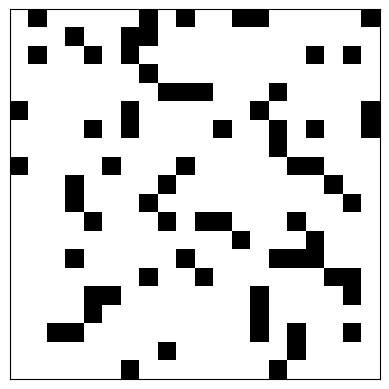

In [6]:
H, L = 20, 20
random.seed(42)
np.random.seed(42)
error_rate = 0.2
p_dyn = 0.0000001
lattice = np.zeros((H, L), dtype=int)
lattice = monte_carlo_error(lattice, error_rate= error_rate, num_steps=1)
plot_checkerboard(lattice)
random.seed(43)
np.random.seed(43)
# lattice = bkl(lattice, error_rate= p_dyn, steps=2000)[0]



(<Axes: >, <matplotlib.image.AxesImage at 0x10dd7d310>)

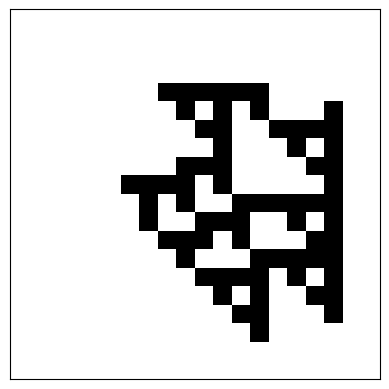

In [7]:
lattice = bkl(lattice, error_rate= p_dyn, steps=2000)[0]
plot_checkerboard(lattice)

(<Axes: >, <matplotlib.image.AxesImage at 0x135520f50>)

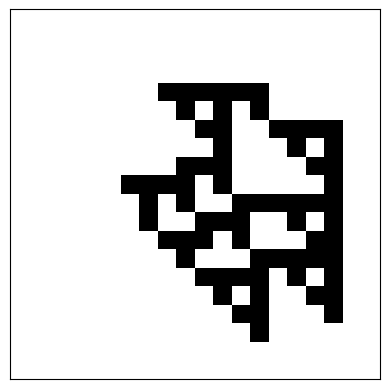

In [12]:
lattice = bkl(lattice, error_rate= p_dyn, steps=3)[0]
plot_checkerboard(lattice)

(<Axes: >, <matplotlib.image.AxesImage at 0x10fe0a0d0>)

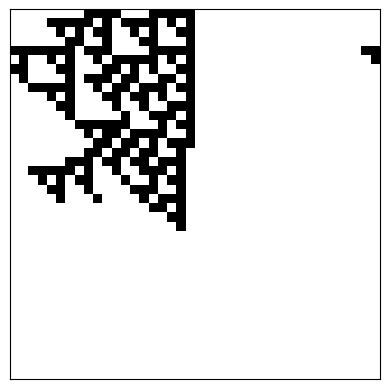

In [108]:
lat = np.zeros((2*H, 2*L), dtype=int)
latt = monte_carlo_error(lattice, error_rate= error_rate, num_steps=1)
lat[:H, :L] = latt
lat = bkl(lat, error_rate= p_dyn, steps=5000)[0]
plot_checkerboard(lat)

(<Axes: >, <matplotlib.image.AxesImage at 0x139860a50>)

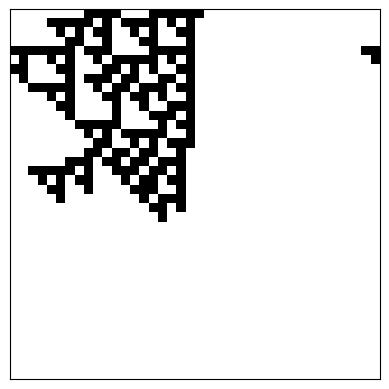

In [110]:
lat = bkl(lat, error_rate= p_dyn, steps=5000)[0]
plot_checkerboard(lat)

(<Axes: >, <matplotlib.image.AxesImage at 0x1103eafd0>)

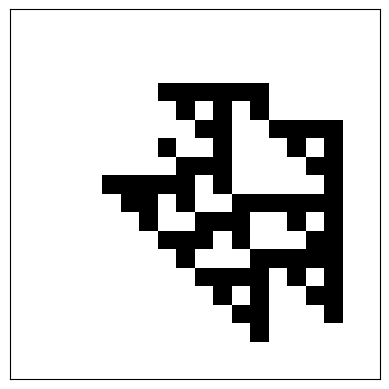

In [95]:
# lattice = np.roll(lattice, shift=(2, 0), axis=(0,1))  # Shift rows down by 1 to match syndrome order
lattice = bkl(lattice, error_rate= p_dyn, steps=2000)[0]
plot_checkerboard(lattice)

(<Axes: >, <matplotlib.image.AxesImage at 0x139885590>)

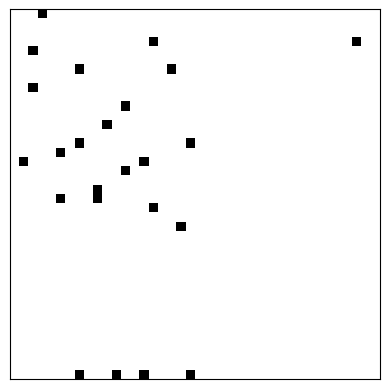

In [109]:
plot_checkerboard(syndrome_detector(lat))

In [81]:
patterns = error_clustering(lattice)
patterns

{0: [(np.int64(0), np.int64(7)),
  (np.int64(99), np.int64(6)),
  (np.int64(94), np.int64(93)),
  (np.int64(94), np.int64(94)),
  (np.int64(94), np.int64(95)),
  (np.int64(94), np.int64(96)),
  (np.int64(94), np.int64(97)),
  (np.int64(94), np.int64(98)),
  (np.int64(94), np.int64(99)),
  (np.int64(95), np.int64(0)),
  (np.int64(95), np.int64(1)),
  (np.int64(95), np.int64(2)),
  (np.int64(95), np.int64(94)),
  (np.int64(95), np.int64(96)),
  (np.int64(95), np.int64(98)),
  (np.int64(96), np.int64(2)),
  (np.int64(96), np.int64(95)),
  (np.int64(96), np.int64(96)),
  (np.int64(97), np.int64(3)),
  (np.int64(97), np.int64(4)),
  (np.int64(97), np.int64(5)),
  (np.int64(97), np.int64(6)),
  (np.int64(97), np.int64(7)),
  (np.int64(97), np.int64(8)),
  (np.int64(97), np.int64(9)),
  (np.int64(97), np.int64(96)),
  (np.int64(98), np.int64(5)),
  (np.int64(98), np.int64(7)),
  (np.int64(98), np.int64(10)),
  (np.int64(98), np.int64(11)),
  (np.int64(98), np.int64(12)),
  (np.int64(99), np.i

In [82]:
from collections import Counter

def cluster_row_span_distribution(clusters):

    row_spans = []
    for members in clusters.values():
        rows = [r for r, c in members]
        span = max(rows) - min(rows)
        row_spans.append(span)

    return dict(sorted(Counter(row_spans).items()))

In [83]:
cluster_row_span_distribution(patterns)

{np.int64(1): 20,
 np.int64(2): 2,
 np.int64(3): 5,
 np.int64(4): 1,
 np.int64(5): 5,
 np.int64(6): 4,
 np.int64(7): 3,
 np.int64(8): 1,
 np.int64(9): 2,
 np.int64(10): 5,
 np.int64(13): 2,
 np.int64(15): 1,
 np.int64(19): 1,
 np.int64(21): 1,
 np.int64(26): 1,
 np.int64(34): 1,
 np.int64(37): 1,
 np.int64(99): 4}

Text(0, 0.5, 'Number of clusters')

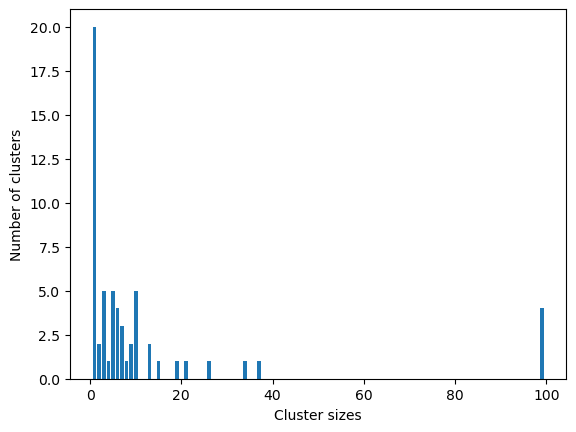

In [85]:
keys, values = zip(*cluster_row_span_distribution(patterns).items())
plt.bar(keys, values)
plt.xlabel('Cluster sizes')
plt.ylabel('Number of clusters')

In [4]:
def spin_classify(patterns:list, ordering = False):
    flat_each = [ [x for row in m for x in row] for m in patterns ]
    keys = []
    for flat in flat_each:
        bitstr = ''.join('1' if b else '0' for b in flat)
        keys.append(bitstr)
    classes = defaultdict(int)
    for key in keys:
        if key not in classes:
            classes[key] = 0
        classes[key] +=1 
    if ordering == True:
        indices = {}
        for key in keys:
           indices[key]= [i for i, s in enumerate(keys) if s == key]
        return classes, indices
    else:
        return classes

from itertools import product

def all_binary_matrices(n_rows: int, n_cols: int):
    """
    Yield every n_rows x n_cols matrix with entries in {0,1}, row-major order.
    Each matrix is a list of lists of ints.
    Total count: 2**(n_rows * n_cols).
    """
    for bits in product((0, 1), repeat=n_rows * n_cols):
        yield [list(bits[i*n_cols:(i+1)*n_cols]) for i in range(n_rows)]

def decstr_to_bits_width(s: str, width: int, twos_complement: bool = False) -> str:
    n = int(s.strip())
    if n >= 0:
        return format(n, f'0{width}b')[-width:]      # trim if too long
    else:
        # two's complement within given width
        return format((1 << width) + n, f'0{width}b')[-width:]




from collections import Counter
from typing import Iterable, Callable, Any, Optional

def is_subset(
    A: Iterable[Any],
    B: Iterable[Any],
    mode: str = "set",
    key: Optional[Callable[[Any], Any]] = None,
) -> bool:
    """
    Check if A is a 'subset' of B under different notions:

    mode:
      - 'set'        : ignore multiplicities and order (mathematical subset)
      - 'multiset'   : respect multiplicities (bag/multiset subset)
      - 'subsequence': order matters but elements need not be contiguous

    key:
      Optional transformer to make elements hashable/normalized
      (e.g., key=tuple for lists-of-lists; key=str for bitstrings).
    """
    if key is None:
        key = lambda x: x

    if mode == "set":
        try:
            return set(map(key, A)).issubset(set(map(key, B)))
        except TypeError:
            # fallback if elements aren’t hashable: materialize and scan
            A_norm = list(map(key, A))
            B_norm = list(map(key, B))
            return all(x in B_norm for x in A_norm)

    elif mode == "multiset":
        # counts in A must be <= counts in B for every element
        A_cnt = Counter(map(key, A))
        B_cnt = Counter(map(key, B))
        return all(A_cnt[x] <= B_cnt.get(x, 0) for x in A_cnt)

    elif mode == "subsequence":
        # each element of A must appear in B in order (not necessarily contiguously)
        it = iter(map(key, B))
        try:
            return all(next(x for x in it if x == key(a)) or True for a in A)
        except StopIteration:
            return False

    else:
        raise ValueError("mode must be 'set', 'multiset', or 'subsequence'")


def average_on_time_edges_left_hold(t, x, nbins):
    """
    Left-hold average across realizations on common time bin edges.

    Parameters
    ----------
    t : (R, T) array
        Times for each realization. Can include NaNs as padding.
    x : (R, T) array
        Values for each realization. Can include NaNs as padding.
    nbins : int
        Number of uniform bins. Output has nbins+1 edges.

    Returns
    -------
    edges : (nbins+1,) array
        Uniform bin-edge times spanning [global min(t), global max(t)].
    mean : (nbins+1,) array
        Mean across realizations at each edge (NaN-ignored).
    """
    t = np.asarray(t, dtype=float)
    x = np.asarray(x, dtype=float)
    if t.shape != x.shape or t.ndim != 2:
        raise ValueError(f"t and x must be 2D with the same shape. Got t={t.shape}, x={x.shape}")

    t_min = np.nanmin(t)
    t_max = np.nanmax(t)
    if not np.isfinite(t_min) or not np.isfinite(t_max) or t_min == t_max:
        raise ValueError("Invalid global time range (check for NaNs or constant times).")

    edges = np.linspace(t_min, t_max, nbins + 1)

    R, _ = t.shape
    values_on_edges = np.full((R, edges.size), np.nan)

    for i in range(R):
        mask = np.isfinite(t[i]) & np.isfinite(x[i])
        ti = t[i, mask]
        xi = x[i, mask]
        if ti.size == 0:
            continue

        # sort by time
        # order = np.argsort(ti)
        # ti = ti[order]
        # xi = xi[order]

        idx = np.searchsorted(ti, edges, side="right") 
        valid = (idx >= 0) & (edges <= ti[-1])
        values_on_edges[i, valid] = xi[idx[valid]]

    mean = np.nanmean(values_on_edges, axis=0)
    return edges, mean


In [5]:


def average_energy_on_edges_left_hold(t, E, nbins):
    """
    Ensemble-average unevenly-sampled energy trajectories by left-hold resampling
    onto common uniform bin edges.

    Inputs
    ------
    t, E : (R, T) arrays
        Times and energies for each realization (uneven sampling allowed).
        Can use NaN padding for shorter trajectories.

    Output
    ------
    edges : (nbins+1,) array
    mean  : (nbins+1,) array
        Mean energy evaluated at each edge time using left-hold per realization.
    """
    t = np.asarray(t, dtype=float)
    E = np.asarray(E, dtype=float)
    if t.ndim != 2 or E.ndim != 2 or t.shape != E.shape:
        raise ValueError(f"t and E must be 2D arrays with the same shape. Got t={t.shape}, E={E.shape}")

    t_min = np.nanmin(t)
    t_max = np.nanmax(t)
    if not np.isfinite(t_min) or not np.isfinite(t_max) or t_max <= t_min:
        raise ValueError("Invalid global time window (check for NaNs or degenerate times).")
    edges = np.linspace(t_min, t_max, nbins + 1)
    R, _ = t.shape
    Y = np.full((R, edges.size), np.nan)

    for i in range(R):
        # keep only valid (time, energy) pairs
        m = np.isfinite(t[i]) & np.isfinite(E[i])
        if not np.any(m):
            continue
        ti = t[i, m]
        Ei = E[i, m]

        # sort by time
        order = np.argsort(ti)
        ti = ti[order]
        Ei = Ei[order]
        idx = np.searchsorted(ti, edges, side="right") - 1

        ok = idx >= 0
        Y[i, ok] = Ei[idx[ok]]

        Y[i, edges < ti[0]] = Ei[0]

        Y[i, edges > ti[-1]] = Ei[-1]

    mean = np.nanmean(Y, axis=0)
    return edges, mean


import numpy as np

def average_on_time_edges_from_endtimes(t_end, x_interval, nbins, extend_right=False):
    """
    t_end[i,k] = end time of interval k (T_{k+1})
    x_interval[i,k] = value on interval [T_k, T_{k+1})
    """
    t_end = np.asarray(t_end, float)
    x_interval = np.asarray(x_interval, float)
    if t_end.shape != x_interval.shape or t_end.ndim != 2:
        raise ValueError("t_end and x_interval must be 2D with same shape")

    # important: include t=0 as the start of physical time
    t_min = 0.0
    t_max = np.nanmax(t_end)
    edges = np.linspace(t_min, t_max, nbins + 1)

    R, _ = t_end.shape
    out = np.full((R, edges.size), np.nan)

    for i in range(R):
        mask = np.isfinite(t_end[i]) & np.isfinite(x_interval[i])
        ti = t_end[i, mask]
        xi = x_interval[i, mask]
        if ti.size == 0:
            continue

        # should already be increasing, but safe:
        order = np.argsort(ti)
        ti = ti[order]
        xi = xi[order]

        # interval index k such that edge is inside [T_k, T_{k+1})
        idx = np.searchsorted(ti, edges, side="right")  # NOTE: no "-1"

        if extend_right:
            idx = np.clip(idx, 0, xi.size - 1)
            valid = (idx >= 0)
        else:
            valid = (idx >= 0) & (idx < xi.size) & (edges < ti[-1])

        out[i, valid] = xi[idx[valid]]

    mean = np.nanmean(out, axis=0)
    return edges, mean


In [6]:
import numpy as np

def compute_b(a):
    a = np.asarray(a)

    
    if a.dtype.kind in "fc":  # float/complex
        a = (a > 0.5).astype(np.uint8)   
      
    else:
        a = (a.astype(np.int64) & 1).astype(np.uint8)

    a_i1_j  = np.roll(a, -1, axis=0)          # a[i+1,j]
    a_i1_j1 = np.roll(a_i1_j, -1, axis=1)     # a[i+1,j+1]
    return a ^ a_i1_j ^ a_i1_j1               # XOR

def compute_dE(lattice, i, j):
    lat = np.copy(lattice)
    dE = compute_b(lat) - compute_b(lat[i, j]^1)
    return dE

def toggle_b_for_spin(b, i, j):
    H, L = b.shape
    b[i % H, j % L] ^= 1
    b[(i-1) % H, j % L] ^= 1
    b[(i-1) % H, (j-1) % L] ^= 1

# def neighbor_avg_tri(phi):
#     return (
#         np.roll(phi, (+1, 0), axis=(0,1)) +
#         np.roll(phi, (-1, 0), axis=(0,1)) +
#         np.roll(phi, (0, +1), axis=(0,1)) +
#         np.roll(phi, (0, -1), axis=(0,1)) +
#         np.roll(phi, (+1, +1), axis=(0,1)) +
#         np.roll(phi, (-1, -1), axis=(0,1))
#     ) / 6.0

def neighbor_avg_tri(phi):
    return (
        np.roll(phi, (+2, 0), axis=(0,1)) +
        np.roll(phi, (-2, 0), axis=(0,1)) +
        np.roll(phi, (0, +2), axis=(0,1)) +
        np.roll(phi, (0, -2), axis=(0,1)) +
        np.roll(phi, (+2, +2), axis=(0,1)) +
        np.roll(phi, (-2, -2), axis=(0,1))
    ) / 6.0

def relax_phi(phi, b, alpha=0.2, eta=1.0, n_iter=10):

    b_float = b.astype(phi.dtype)
    for _ in range(n_iter):
        phi = (1 - alpha) * phi + alpha * neighbor_avg_tri(phi) + eta * b_float
    return phi
def flip_score(phi, b, i, j):
    H, L = b.shape
    p0 = (i % H, j % L)
    p1 = ((i-1) % H, j % L)
    p2 = ((i-1) % H, (j-1) % L)

    score = 0.0
    for (x,y) in (p0,p1,p2):
        score += phi[x,y] * (2*b[x,y] - 1)
    return score

def pick_spin_biased(cands, phi, b, kappa=0.2):
    # weights ∝ exp(kappa*score)
    scores = np.array([flip_score(phi, b, i, j) for (i,j) in cands], dtype=float)
    # stable softmax
    scores -= scores.max()
    w = np.exp(kappa * scores)
    w /= w.sum()
    idx = np.random.choice(len(cands), p=w)
    return cands[idx]

def score_spin(i, j, b, phi):
    H, L = b.shape
    p0 = (i % H, j % L)
    p1 = ((i-1) % H, j % L)
    p2 = ((i-1) % H, (j-1) % L)
    s = 0.0
    for (x,y) in (p0, p1, p2):
        s += phi[x,y] * (2*b[x,y] - 1)   # +phi if b=1 else -phi
    return s

def attempt_random_field_flip(a, b, phi, beta_f=0.5, rng=np.random):
    """
    Propose uniform random spin. Accept if score>=0,
    else accept with prob exp(beta_f*score) (since score is negative).
    """
    a = as_bits01(a)
    H, L = a.shape
    i = rng.randint(H)
    j = rng.randint(L)

    sc = score_spin(i, j, b, phi)  # uses sign = +/-1, no uint underflow

    if sc >= 0:
        a[i, j] ^= 1
        toggle_b_for_spin(b, i, j)
        return True, (i, j), sc, a

    if np.log(rng.rand()) < beta_f * sc:
        a[i, j] ^= 1
        toggle_b_for_spin(b, i, j)
        return True, (i, j), sc, a

    return False, (i, j), sc, a


def run_random_field_decoder(lattice, steps,
                             alpha=0.2, eta=1.0, n_iter=10,
                             M_cap=10.0, kappa=0.2,
                             record_every=1):
    a = lattice.copy()
    b = compute_b(a)
    phi = np.zeros_like(b, dtype=float)

    defect_hist = []
    accept_hist = []
    score_hist  = []

    for t in range(steps):
        phi = relax_phi(phi, b, alpha=alpha, eta=eta, n_iter=n_iter, M_cap=M_cap)

        accepted, (i,j), sc = attempt_random_field_flip(a, b, phi, kappa=kappa, M_cap=M_cap)

        if (t % record_every) == 0:
            defect_hist.append(int(b.sum()))
            accept_hist.append(int(accepted))
            score_hist.append(float(sc))

    return a, np.array(defect_hist), np.array(accept_hist), np.array(score_hist)

import numpy as np

def as_bits01(a):
    a = np.asarray(a)
    if a.dtype.kind in "fc":           
        a = (a > 0.5).astype(np.uint8) 
    else:
        a = (a.astype(np.int64) & 1).astype(np.uint8)
    return a




In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("/Users/tomarr626/Downloads/ThermalTrails/full_error_history.csv")

# optional: keep rows ordered
df = df.sort_values(["T", "w", "h", "seed", "event_id"]).reset_index(drop=True)

w = int(df.iloc[0]["w"])
h = int(df.iloc[0]["h"])
n = w * h

all_A_Z = np.array([
    [int(c) for c in state.split("|")[0]]
    for state in df["state"]
], dtype=int)

print(all_A_Z.shape)   # (num_rows, w*h)

(7271539, 54)


In [14]:
import pandas as pd

def block_to_2d_list(block: str, w: int, h: int):
    if len(block) != w * h:
        raise ValueError(f"Expected block length {w*h}, got {len(block)}")
    return [[int(c) for c in block[r*w:(r+1)*w]] for r in range(h)]

def build_seed_history_3dlist(csv_file: str):
    df = pd.read_csv(csv_file)

    # sort so each history is in event order
    df = df.sort_values(["T", "w", "h", "seed", "event_id"]).reset_index(drop=True)

    seeds_histories = []
    seeds_times =[]

    # one history per (T,w,h,seed); if T,w,h are fixed, this is effectively per seed
    for (T, w, h, seed), hist in df.groupby(["T", "w", "h", "seed"], sort=True):
        hist = hist.sort_values("event_id")

        history_2d = []
        time_2d = []
        for _, row in hist.iterrows():
            state = row["state"]
            time = row["time"]
            parts = state.split("|")

            # A_Z is the first block
            A_Z_block = parts[0]
            A_Z_2d = block_to_2d_list(A_Z_block, int(w), int(h))

            history_2d.append(A_Z_2d)
            time_2d.append(time)

        seeds_histories.append(history_2d)
        seeds_times.append(time_2d)

    return seeds_histories, seeds_times

In [15]:
all_error, all_time = build_seed_history_3dlist("/Users/tomarr626/Downloads/ThermalTrails/full_error_history.csv")
H = 9; L = 6; seeds = 2000


In [91]:
error_rate = 0.0001
steps = max(len(hist) for hist in all_time)
# en_hist_total = np.zeros((seeds,steps))
# mem_time_total = np.zeros((seeds,steps))

en_hist_total = []
mem_time_total = []
beta = math.log((3+error_rate)/error_rate)/3
E_steady = 1/(1 + np.exp(beta))
fracs_1 = np.zeros(seeds)
for seed in range(seeds):
    history = all_error[seed]
    en_list = [energy(np.array(lst)) for lst in history]
    time_list = all_time[seed]
    en_hist_total.append(en_list[:])
    # en_hist_total[seed] = en_list[:]
    # mem_time_total[seed] = time_list[:]
    dt_list = np.diff(time_list, prepend=0)
    total_time = time_list[-1]
    frac_1 = np.array(en_list[:-2]) * dt_list[2:]
    fracs_1[seed] = np.sum(frac_1)/(total_time* H * L)


#       time binning
# mean_times, mean_ens = average_on_time_edges_from_endtimes(mem_time_total, en_hist_total, nbins=1600)
# # mean_times = np.mean(time_lists, axis=0)
# mean_ens = np.array(mean_ens)/(H * L)
# mean_mean_en = np.mean(mean_ens[:], axis=0)
# mean_frac = np.mean(fracs_1)


# plt.plot(mean_times, mean_ens, '-', label = f'mean energy over {seeds} runs')
# plt.axhline(y = E_steady, color='r', linestyle='--', label =rf'steady state energy = $\frac{{1}}{{1 + e^{{\beta}}}} = {E_steady}$')
# # plt.axhline(y=1/(1+np.exp(beta)), color='r', linestyle='--', label =rf'Spin 1 frac = $\frac{{q}}{{p+q}}= {q/(p+q)}$')
# plt.axhline(y=mean_mean_en, color='b', linestyle='--', label =fr'Spin 1 mean = {mean_mean_en:.3f}')
# plt.axhline(y=mean_frac, color='g', linestyle='--', label =fr'Spin 1 $\Delta t$ frac = {mean_frac:.6f}')
# plt.title(f'NM lattice, error rate={error_rate}, H ={H}, L={L}, random seeds ={seeds}')
# plt.xlabel('Physical time steps')
# plt.ylabel('Mean Energy')
# # plt.xlim(0, 50)
# plt.legend()
# plt.show()
# print('differences between theore and numerical average', mean_mean_en - E_steady)
# print('differences between theore and numerical average with time weight', mean_frac - E_steady)
    

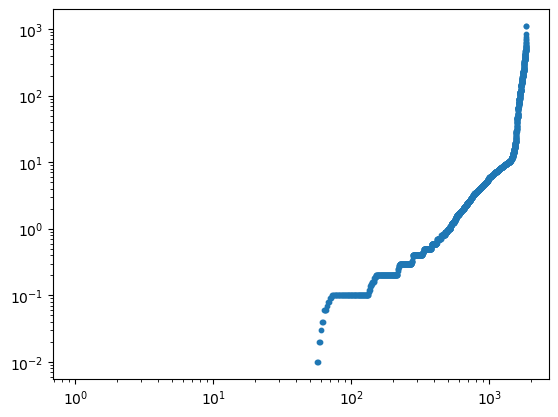

In [92]:
sor = sorted(dt_list)
plt.scatter(np.arange(len(sor)), sor, s=10)
plt.xscale('log')
plt.yscale('log')



In [97]:
fracs = np.zeros(seeds)
for seed in range(seeds):
    en_list = en_hist_total[seed]
    dt_list = np.diff(all_time[seed])
    frac = np.array(en_list[1:]) * dt_list[:]
    fracs[seed] = np.sum(frac)/(total_time* H * L)

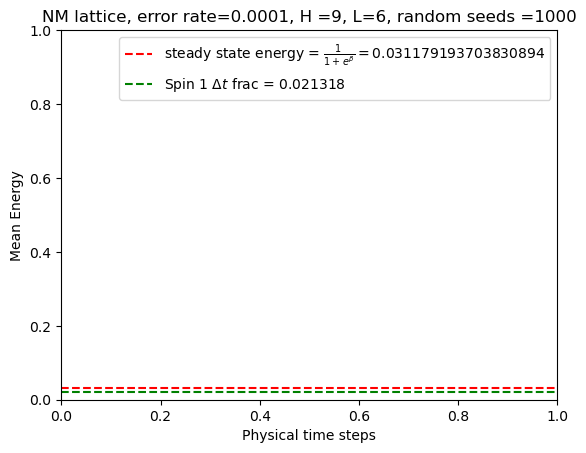

In [98]:
mean_frac = np.mean(fracs)
plt.axhline(y = E_steady, color='r', linestyle='--', label =rf'steady state energy = $\frac{{1}}{{1 + e^{{\beta}}}} = {E_steady}$')
# plt.axhline(y=1/(1+np.exp(beta)), color='r', linestyle='--', label =rf'Spin 1 frac = $\frac{{q}}{{p+q}}= {q/(p+q)}$')
# plt.axhline(y=mean_mean_en, color='b', linestyle='--', label =fr'Spin 1 mean = {mean_mean_en:.3f}')
plt.axhline(y=mean_frac, color='g', linestyle='--', label =fr'Spin 1 $\Delta t$ frac = {mean_frac:.6f}')
plt.title(f'NM lattice, error rate={error_rate}, H ={H}, L={L}, random seeds ={seeds}')
plt.xlabel('Physical time steps')
plt.ylabel('Mean Energy')
# plt.xlim(0, 50)
plt.legend()
plt.show()

In [39]:
H = 3
L = 3
error_rate = 0.001
beta = math.log((3+error_rate)/error_rate)/3
steps = 100
seeds = 400
lattice = np.zeros([H,L])
E = np.zeros((seeds,steps), dtype=int)
phi = np.zeros_like(lattice, dtype=float)  
for s in range(seeds):
    random.seed(s)
    lattice = np.zeros([H,L])
    for t in range(steps):  
        lattice = monte_carlo_error(lattice, 1, 0.01)
        lattice = as_bits01(lattice)
        b = compute_b(lattice)                    
             
        phi = relax_phi(phi, b, alpha=0.45, eta=1.0, n_iter=5)
        accept = False
        while not accept: 
            accept, (i,j), sc, lattice = attempt_random_field_flip(lattice, b, phi)
        # if accept: 
        #     lattice[i,j] ^= 1
        E[s,t] = np.sum(b)
        



/var/folders/b0/yd0t1s1d3csclx8j2np0lfvc0000gn/T/ipykernel_2740/3108707189.py:67: RuntimeWarning: overflow encountered in scalar subtract
  s += phi[x,y] * (2*b[x,y] - 1)   # +phi if b=1 else -phi


/var/folders/b0/yd0t1s1d3csclx8j2np0lfvc0000gn/T/ipykernel_40265/1766842857.py:99: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(out, axis=0)


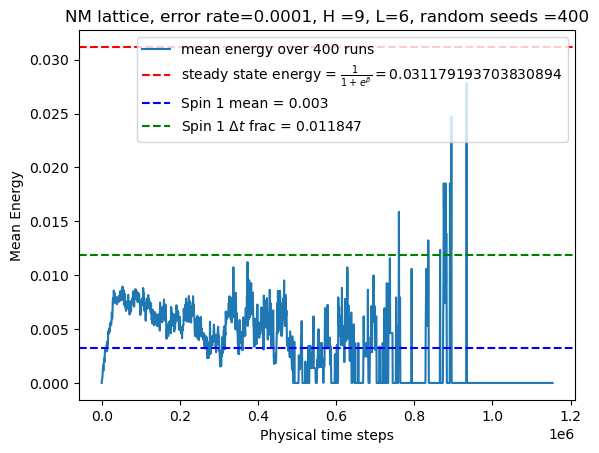

differences between theore and numerical average -0.027975343208543935
differences between theore and numerical average with time weight -0.01933247816017669


In [100]:
H = 9
L = 6
error_rate = 0.0001
beta = math.log((3+error_rate)/error_rate)/3
E_steady = 1/(1 + np.exp(beta))  # steady state energy
steps = 15000
seeds = 400
t_start = 0
t_end = 1
en_lists = np.zeros((seeds, steps-t_start))
time_lists = np.zeros((seeds, steps-t_start))
correlations = []
error_patterns = []
syndromes = []
# spin_config1 = []
spin_config2 = []
fracs = np.zeros(seeds)

fracs = np.zeros(seeds)
for seed in range(seeds):
    x = lattice_space(H, L)
    logicals = logical_operators(x)
    logical = 3
    lattice = logicals[logical].copy()
    # lattice = monte_carlo_error(lattice, 1, 0.4)
    
    random.seed(seed)

    lattice, energy_list, time_list, spin_config2, total_R, spin_class_check = bkl(lattice,  steps,  error_rate)
    en_lists[seed] = energy_list[t_start:]
    time_lists[seed] = np.cumsum(time_list[t_start:])
    total_time = sum(time_list[t_start:-t_end])
    frac = [energy_list[spin_i] * time_list[spin_i] for spin_i in range(t_start, steps - t_end)]
    fracs[seed] = sum(frac)/(total_time* H * L)

    # spin_config2.append(copy.deecopy(lattice))
    # error_patterns.append((lattice.copy()+ logicals[logical].copy()) % 2)

#       time binning
mean_times, mean_ens = average_on_time_edges_from_endtimes(time_lists, en_lists, nbins=1600)
# mean_times = np.mean(time_lists, axis=0)
mean_ens = np.array(mean_ens)/(H * L)
mean_mean_en = np.mean(mean_ens[:-t_end], axis=0)
mean_frac = np.mean(fracs)


plt.plot(mean_times, mean_ens, '-', label = f'mean energy over {seeds} runs')
plt.axhline(y = E_steady, color='r', linestyle='--', label =rf'steady state energy = $\frac{{1}}{{1 + e^{{\beta}}}} = {E_steady}$')
# plt.axhline(y=1/(1+np.exp(beta)), color='r', linestyle='--', label =rf'Spin 1 frac = $\frac{{q}}{{p+q}}= {q/(p+q)}$')
plt.axhline(y=mean_mean_en, color='b', linestyle='--', label =fr'Spin 1 mean = {mean_mean_en:.3f}')
plt.axhline(y=mean_frac, color='g', linestyle='--', label =fr'Spin 1 $\Delta t$ frac = {mean_frac:.6f}')
plt.title(f'NM lattice, error rate={error_rate}, H ={H}, L={L}, random seeds ={seeds}')
plt.xlabel('Physical time steps')
plt.ylabel('Mean Energy')
# plt.xlim(0, 50)
plt.legend()
plt.show()
print('differences between theore and numerical average', mean_mean_en - E_steady)
print('differences between theore and numerical average with time weight', mean_frac - E_steady)

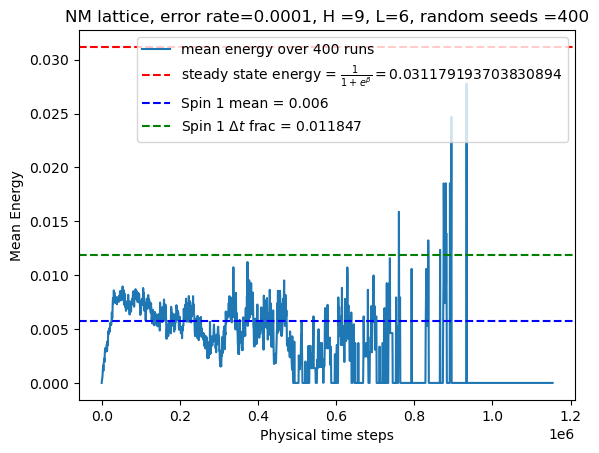

differences between theore and numerical average -0.8151115680573975
differences between theore and numerical average with time weight -0.6200441981859642


In [101]:
mean_mean_en = np.mean(mean_ens[100:-1000], axis=0)
mean_frac = np.mean(fracs)


plt.plot(mean_times, mean_ens, '-', label = f'mean energy over {seeds} runs')
plt.axhline(y = E_steady, color='r', linestyle='--', label =rf'steady state energy = $\frac{{1}}{{1 + e^{{\beta}}}} = {E_steady}$')
# plt.axhline(y=1/(1+np.exp(beta)), color='r', linestyle='--', label =rf'Spin 1 frac = $\frac{{q}}{{p+q}}= {q/(p+q)}$')
plt.axhline(y=mean_mean_en, color='b', linestyle='--', label =fr'Spin 1 mean = {mean_mean_en:.3f}')
plt.axhline(y=mean_frac, color='g', linestyle='--', label =fr'Spin 1 $\Delta t$ frac = {mean_frac:.6f}')
plt.title(f'NM lattice, error rate={error_rate}, H ={H}, L={L}, random seeds ={seeds}')
plt.xlabel('Physical time steps')
plt.ylabel('Mean Energy')
# plt.xlim(0, 50)
plt.legend()
plt.show()
print('differences between theore and numerical average', (mean_mean_en - E_steady)/E_steady)
print('differences between theore and numerical average with time weight', (mean_frac - E_steady)/E_steady)

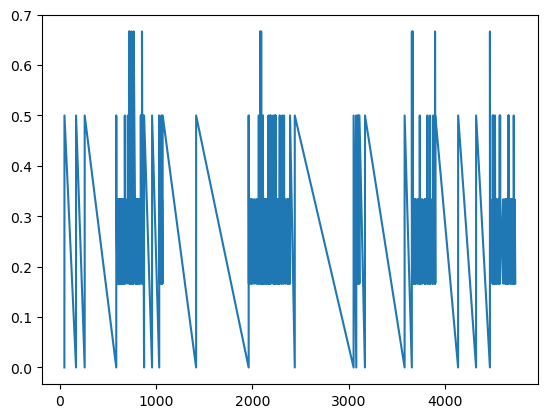

In [70]:
plt.plot(time_lists[0], en_lists[0]/(H*L), '-', label = f'energy over time for one run')

(0.0, 200.0)

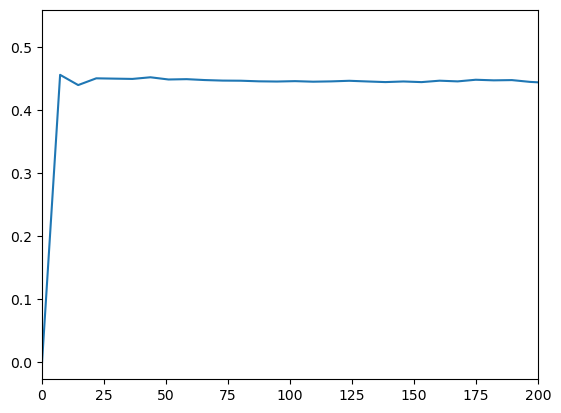

In [56]:
plt.plot(mean_times, mean_ens, '-', label = f'mean energy over {seeds} runs')
plt.xlim(0,200)

In [76]:
lattice = bkl(lattice,  steps,  error_rate, debug=False, config=False)

In [77]:
print(np.shape(lattice))

(8, 8)


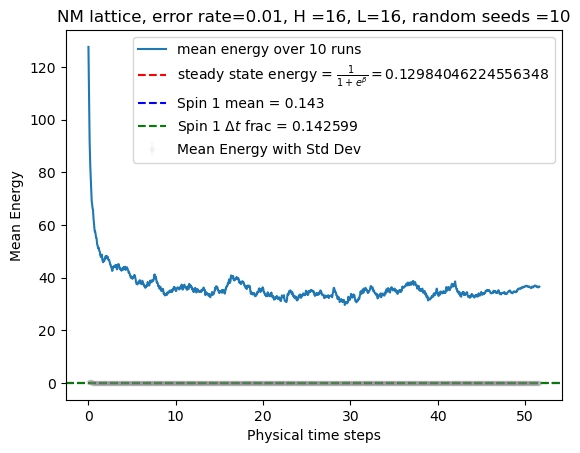

differences between theore and numerical average 0.012728020909873489
differences between theore and numerical average with time weight 0.012758606077140217


In [12]:
plt.plot(mean_times, mean_ens*256, '-', label = f'mean energy over {seeds} runs')
plt.axhline(y = E_steady, color='r', linestyle='--', label =rf'steady state energy = $\frac{{1}}{{1 + e^{{\beta}}}} = {E_steady}$')
plt.errorbar(mean_times, mean_ens, yerr=std/(H*L*np.sqrt(seeds)), fmt='.', color='gray', alpha=0.05, label='Mean Energy with Std Dev')
# plt.axhline(y=1/(1+np.exp(beta)), color='r', linestyle='--', label =rf'Spin 1 frac = $\frac{{q}}{{p+q}}= {q/(p+q)}$')
plt.axhline(y=mean_mean_en, color='b', linestyle='--', label =fr'Spin 1 mean = {mean_mean_en:.3f}')
plt.axhline(y=mean_frac, color='g', linestyle='--', label =fr'Spin 1 $\Delta t$ frac = {mean_frac:.6f}')
plt.title(f'NM lattice, error rate={error_rate}, H ={H}, L={L}, random seeds ={seeds}')
plt.xlabel('Physical time steps')
plt.ylabel('Mean Energy')
# plt.xlim(0, 50)
plt.legend()
plt.show()
print('differences between theore and numerical average', mean_mean_en - E_steady)
print('differences between theore and numerical average with time weight', mean_frac - E_steady)

[0.12536741]
[0.31356667]


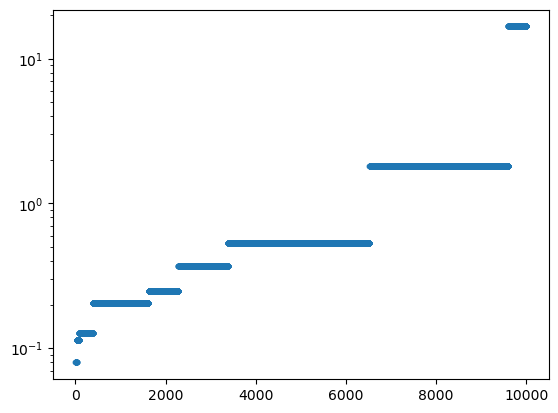

In [10]:
print(fracs)
print(np.mean(en_lists/6, axis=1))
t = sorted(time_list, key=lambda x: abs(x))
plt.scatter(np.arange(len(time_list)), t, s=10)
plt.yscale('log')

In [14]:
print(energy_list)

[np.float64(0.0), np.float64(3.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(2.0), np.float64(3.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(4.0), np.float64(1.0), np.float64(4.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(2.

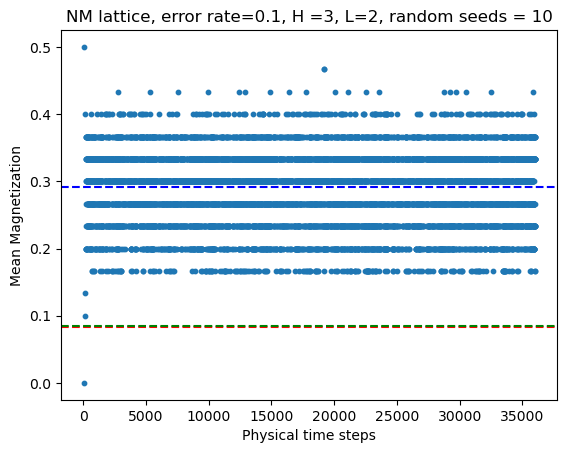

differences between theore and numerical average 0.20867586758675866
differences between theore and numerical average with time weight 0.002088323205510653


In [18]:
plt.scatter(mean_times, mean_ens, s=10, label = f'mean mag over {seeds} runs')
plt.axhline(y = E_steady, color='r', linestyle='--', label =rf'steady state energy = $\frac{{1}}{{1 + e^{{\beta}}}} = {E_steady}$')
# plt.axhline(y=1/(1+np.exp(beta)), color='r', linestyle='--', label =rf'Spin 1 frac = $\frac{{q}}{{p+q}}= {q/(p+q)}$')
plt.axhline(y=mean_mean_en, color='b', linestyle='--', label =fr'Spin 1 mean = {mean_mean_en:.3f}')
plt.axhline(y=mean_frac, color='g', linestyle='--', label =fr'Spin 1 $\Delta t$ frac = {mean_frac:.6f}')
plt.title(f'NM lattice, error rate={error_rate}, H ={H}, L={L}, random seeds = {seeds}')
plt.xlabel('Physical time steps')
plt.ylabel('Mean Magnetization')
# plt.xlim(0, 50)
plt.show()
print('differences between theore and numerical average', mean_mean_en - E_steady)
print('differences between theore and numerical average with time weight', mean_frac - E_steady)

In [8]:
print(time_list[:50])

[np.float64(27.168849454172086), np.float64(0.43362191438391684), np.float64(280.33305743079956), np.float64(0.023529007639895638), np.float64(60.919022558357995), np.float64(0.06958443522657379), np.float64(19.539737470377464), np.float64(0.010959247927288258), np.float64(0.7552234772992947), np.float64(8.677133406126046), np.float64(0.2777996971441031), np.float64(8.063571405177008), np.float64(0.15159316570841003), np.float64(0.2469760397012927), np.float64(0.16086940553273435), np.float64(0.6777638526943622), np.float64(0.16557218694049824), np.float64(0.25228180164782377), np.float64(0.13560836481019992), np.float64(1.0057593115049985), np.float64(0.052461724283974574), np.float64(0.024136786469268676), np.float64(0.2609371641969474), np.float64(2.5023016330172663), np.float64(0.01495786436998991), np.float64(6.165938469827752), np.float64(0.0451346665450122), np.float64(3.237796373123002), np.float64(0.8227746376318248), np.float64(2.0208110970917135), np.float64(0.25330308765401

In [129]:
print(energy_list[:10])
print(time_list[:10])

[np.float64(3.0), np.float64(0.0), np.float64(3.0), np.float64(4.0), np.float64(3.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(2.0)]
[np.float64(27.168849454172086), np.float64(0.43362191438391684), np.float64(280.33305743079956), np.float64(0.023529007639895638), np.float64(0.14507695659928826), np.float64(0.0972432329291121), np.float64(1.1392875248321035), np.float64(0.14598080848053807), np.float64(1.187479717384985), np.float64(8.677133406126046)]


Text(0, 0.5, 'Delta T')

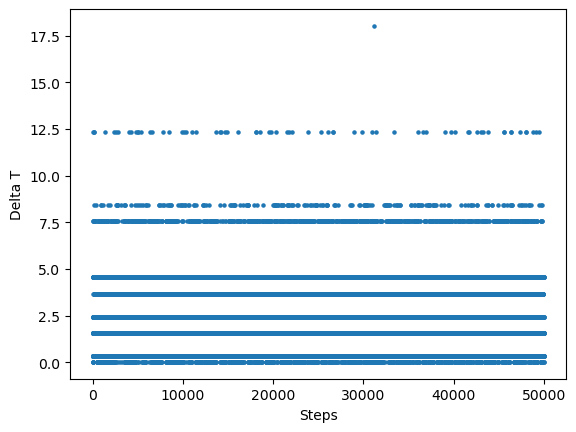

In [22]:
plt.scatter(np.arange(len(time_list)), 1/np.array(time_list), label = 'delta T', s =5)
plt.xlabel('Steps')
plt.ylabel('Delta T')
# plt.ylim(0,2)

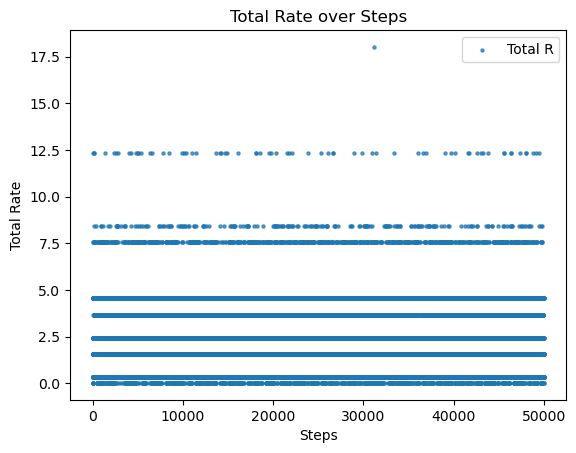

In [20]:
# plt.figure(figsize=(10, 6))
plt.scatter(np.arange(len(total_R)), np.array(total_R), label = 'Total R', alpha=0.7, s=5)
plt.xlabel('Steps')
plt.ylabel('Total Rate')
plt.title('Total Rate over Steps')
# plt.ylim(0, 5)
plt.legend()

In [26]:
H = 2; L =3
energy_microstates = []
microstate = []
for mat in all_binary_matrices(H, L):
    microstate.append(mat)
    energy_microstates.append(energy(np.array(mat)))
    # print(mat)

In [28]:
total_p = 0
total_ms = 0
beta =np.log((3 +0.08)/0.08)/3
for s in microstate:
    e = energy(np.array(s))
    total_p += np.exp(-beta*e)
    total_ms += np.exp(-beta*e) * np.sum(s)

total_ms/(total_p*6)

np.float64(0.419935145092353)

In [15]:
print(np.sum(microstate[11]))

3


In [48]:
from collections import defaultdict
# classes = spin_classify(spin_config)
# classes1,indices = spin_classify(spin_config1[1000:], ordering = True)
classes2,indices1 = spin_classify(spin_config2[3000:], ordering = True)
classes3, indices2 = spin_classify(spin_config2, ordering = True)
# classes2 = spin_classify(spin_config2[1000::10])
# print (classes1)

In [104]:
classes3,indices5 = spin_classify(spin_config2[3000::20], ordering = True)

['110100', '100011', '011111', '001110', '100011', '100011', '111000', '010011', '011111', '001110', '001110', '110100', '010011', '110100', '001101', '001101', '111000', '001110', '001110', '010011', '001110', '110100', '000100', '100011', '001101', '011111', '111000', '001110', '001110', '010011', '101111', '110100', '100011', '010011', '100011', '100101', '001000', '111011', '100011', '010011', '100110', '110100', '100110', '110111', '010011', '001101', '100011', '010000', '010000', '111000', '001110', '001110', '100101', '100011', '010011', '100011', '100101', '100011', '011111', '010011', '000100', '001101', '001101', '110100', '110100', '010011', '000100', '100011', '001101', '011111', '101111', '010000', '100011', '111000', '111000', '001110', '001101', '010011', '000001', '100110', '111000', '110100', '010000', '100000', '010011', '100011', '010011', '100011', '010011', '011001', '100011', '100011', '010011', '110100', '110100', '010011', '010011', '110100', '101111', '001101',

In [25]:
print(spin_config2[indices2['111001'][17]+3000])
# print(spin_config2[3523])

[[1. 1.]
 [1. 0.]
 [0. 1.]]


In [49]:
items = sorted(classes2.items(), key=lambda kv: kv[0])   # by key (asc)
keys, vals_by_key = (list(t) for t in zip(*items)) if items else ([], [])

items1 = sorted(classes3.items(), key=lambda kv: kv[0])   # by key (asc)
keys1, vals_by_key1 = (list(t) for t in zip(*items1)) if items1 else ([], [])

In [72]:
print(sum([len(v) for v in indices2.values()]))

50001


In [142]:
print(len(classes3))
print(2**(H*L))

64
64


In [50]:
decimal_labels = []
binary_labels = []
for i in range(2**(H*L)):
    decimal_labels.append(str(i))
    binary_labels.append(decstr_to_bits_width(str(i), H*L))

# kk = ['0', '1', '2', '3', '4','5', '6', '7', '8','9','10','11','12','13','14','15','16','17','18','19','20','21','22','23','24','25','26','27','28','29','30','31','32','33','34','35','36','37','38','39','40','41','42','43','44','45','46','47','48','49','50','51','52','53','54','55','56','57','58','59','60','61','62','63']

In [51]:
energy_ = np.asarray(energy_microstates, dtype=float)   # your 1D list/array of numbers
labels   = np.asarray(binary_labels, dtype=object)

indices = np.argsort(energy_, kind="mergesort") 
labels_sorted   = labels[indices].tolist()    

In [32]:
print(energy_[indices])
print(labels_sorted)

[0. 1. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 4. 4. 4. 4. 4. 4.
 4. 4. 4. 4. 4. 4. 4. 4. 4. 5. 5. 5. 5. 5. 5. 6.]
['000000', '001101', '001110', '010011', '100011', '110100', '111000', '000011', '001100', '010111', '011011', '011101', '011110', '100111', '101011', '101101', '101110', '110000', '110101', '110110', '111001', '111010', '000001', '000010', '000100', '001000', '010000', '010101', '010110', '011001', '011010', '011111', '100000', '100101', '100110', '101001', '101010', '101111', '110111', '111011', '111101', '111110', '000101', '000110', '001001', '001010', '001111', '010001', '010010', '010100', '011000', '100001', '100010', '100100', '101000', '110011', '111100', '000111', '001011', '011100', '101100', '110001', '110010', '111111']


In [86]:
print(labels)

['0000000000000000' '0000000000000001' '0000000000000010' ...
 '1111111111111101' '1111111111111110' '1111111111111111']


In [43]:
is_subset(keys1, labels_sorted, mode='multiset')

True

In [75]:
print(len(time_list))

50000


In [52]:

t_start = 0
duration = len(spin_config2[t_start:])
amplitudes = np.exp(-beta * np.array(energy_microstates))
P = amplitudes / np.sum(amplitudes)
print(len(P))

# weight averaging using the time steps
# time_frac =[]
time_frac1 =[]
for key in keys1:
    time_frac1.append(sum([time_list[t_start+i] for i in indices2[key]]))
    # try:
    #     time_frac1.append(sum([time_list[i] for i in indices2[key]]))
    # except IndexError:
    #     print(i, key, indices2[key])


order = {lab:i for i, lab in enumerate(labels_sorted)}
idx = np.argsort(np.vectorize(order.get)(keys1))   # order indices for subset labels
sorted_sublabels = np.array(keys1)[idx]
sorted_subvalues = np.array(vals_by_key1)[idx]
P = P[indices]


512


2.4502799511333198


NameError: name 'G_1' is not defined

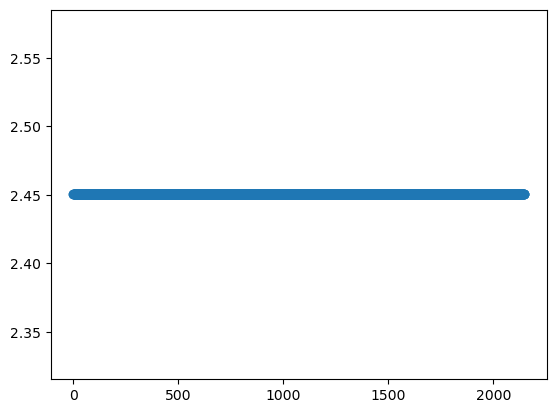

In [96]:
index = '110000'
plt.scatter(np.arange(len([total_R [t_start+i] for i in indices2[index]])), [total_R [t_start+i] for i in indices2[index]], label = index)
# re_0 = [time_list[3000+i] for i in indices2['000000']]
# plt.scatter(np.arange(len(re_0)), re_0, label = 'config 000000')
R_i = [total_R [t_start+i] for i in indices2[index]]
mean_R = np.mean(R_i)
print(mean_R)
beta = math.log((3+error_rate)/error_rate)/3
G = G_1*1 + G_2 *1 +G_3 *4 + G_4 * 0 #+ -3/(np.exp(-beta * 3)-1 )
print(G)
plt.axhline(y=mean_R, color='g',linestyle='--', label = 'mean')
plt.axhline(y=G, color='r', linestyle='--', label = 'theoretical')
plt.xlabel('Steps')
plt.ylabel(f'Total Rate for {index}')
plt.title(f'Total Rate over Steps for {index}')
# plt.xlim(100)
plt.legend()

state = [[0,0],[0,0],[0,0]]
for i in indices2[index]:
    align = np.array_equal(spin_config2[3000+i], state)
    if not align:
        print('not aligned')
        print(i)
        break

In [162]:
G_1= -3/(np.exp(-beta * 3)-1 )
G_2= -1/(np.exp(-beta * 1)-1 )
G_3 = 1/(np.exp(beta * 1)-1 )
G_4 = 3/(np.exp(beta * 3)-1 )
print(G_1*1 + G_2*1 + G_3 *4 + G_4 * 0)
print(G_2*4 + G_3 *1 + G_4 * 1)
print(G_1*6 + G_2*0 + G_3 *0  + G_4 * 0)
print(G_2* 0 + G_3 *3 + G_4 * 3)
print(G_1* 1 + G_3 *0 + G_4 * 5)
print(spin_class_check[indices2[index] [19]+3000])
print(spin_class_check[indices2[index][ 20]+3000])
print(spin_class_check[indices2[index][ 30]+3000])
print(spin_config2[indices2[index][ 19]+3000])
print(spin_config2[indices2[index][ 20]+3000])
print(spin_config2[indices2[index][30]+3000])

4.558349938916651
4.558349938916651
18.018
0.34220996334999015
3.0180000000000002
{np.float64(1.0): [(0, 0), (0, 1), (2, 1)], np.float64(3.0): [(1, 0), (1, 1), (2, 0)]}
{np.float64(1.0): [(0, 0), (0, 1), (2, 1)], np.float64(3.0): [(1, 0), (1, 1), (2, 0)]}
{np.float64(1.0): [(0, 0), (0, 1), (2, 1)], np.float64(3.0): [(1, 0), (1, 1), (2, 0)]}
[[0. 0.]
 [1. 1.]
 [0. 1.]]
[[0. 0.]
 [1. 1.]
 [0. 1.]]
[[0. 0.]
 [1. 1.]
 [0. 1.]]


In [171]:
print(spin_class_check[np.array(indices2[index][15])+3000])

{np.float64(1.0): [(0, 0), (0, 1), (2, 1)], np.float64(3.0): [(1, 0), (1, 1), (2, 0)]}


In [136]:
print(len(spin_class_check))
print(len(spin_config2))

50000
50000


In [164]:
print(spin_config2[indices2['100000'][0]+ 3000])
print(indices2['100000'][0])

[[1. 0.]
 [0. 0.]
 [0. 0.]]
266


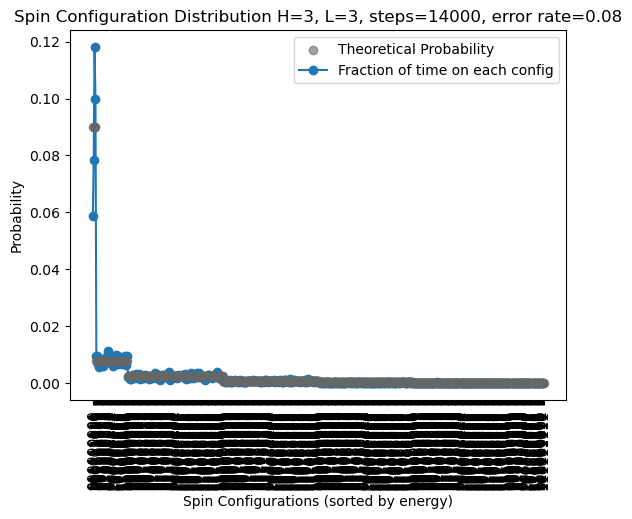

In [53]:
fig, ax = plt.subplots()

order = {lab: i for i, lab in enumerate(labels_sorted)}
x_all = np.arange(len(labels_sorted))
x_sub = np.array([order[lab] for lab in sorted_sublabels])
ax.scatter(x_all, P, color='0.4', label='Theoretical Probability', zorder=5, alpha=0.6)
ax.plot(x_sub, (np.array(time_frac1)[idx]/sum(time_frac1)),'-o', label = 'Fraction of time on each config')

# ax.plot(x_sub, np.array(sorted_subvalues)/duration,'o-',label = 'MC spin config counting')
# plt.bar(decimals, time_frac, edgecolor="black", label=rf'MC $\Delta t$ fraction error rate 0.01,samples 12000')
# ax.bar([pos[s] for s in x1], time_frac1, edgecolor="black", alpha=0.6, label=rf'MC $\Delta t$ fraction error rate {error_rate},samples{T}')

ax.set( xlabel ='Spin Configurations (sorted by energy)',
       ylabel="Probability",
        title=f'Spin Configuration Distribution H={H}, L={L}, steps={duration}, error rate={error_rate}',
)
ax.set_xticks(x_all, labels_sorted, rotation=90)
# ax.set_xlim(-10, 60)
ax.legend()

In [84]:
print(sorted_subvalues/duration)
print(np.array(time_frac1)[idx]/sum(time_frac1))

[2.91063830e-02 5.46808511e-02 5.67872340e-02 6.47234043e-02
 6.15319149e-02 6.13404255e-02 5.86382979e-02 4.45744681e-02
 3.93404255e-02 2.80638298e-02 2.97872340e-02 2.57659574e-02
 2.51702128e-02 2.86170213e-02 2.68510638e-02 2.51914894e-02
 2.73191489e-02 4.28085106e-02 2.81702128e-02 2.80212766e-02
 2.65106383e-02 2.58936170e-02 7.72340426e-03 7.12765957e-03
 7.12765957e-03 7.91489362e-03 7.44680851e-03 5.97872340e-03
 6.42553191e-03 6.57446809e-03 6.19148936e-03 7.44680851e-03
 7.44680851e-03 6.25531915e-03 6.53191489e-03 5.38297872e-03
 5.68085106e-03 8.53191489e-03 8.51063830e-03 7.76595745e-03
 8.00000000e-03 7.46808511e-03 1.17021277e-03 1.08510638e-03
 9.57446809e-04 1.21276596e-03 1.31914894e-03 1.23404255e-03
 1.36170213e-03 1.23404255e-03 1.57446809e-03 1.34042553e-03
 1.53191489e-03 1.59574468e-03 1.08510638e-03 1.51063830e-03
 1.23404255e-03 2.76595745e-04 2.55319149e-04 2.55319149e-04
 2.76595745e-04 1.91489362e-04 1.91489362e-04 4.25531915e-05]
[2.09644000e-02 6.96443

In [ ]:
plt.plot(np.array(kk)[idx],np.array(time_frac1)[idx], 'o-')
plt.xlabel('spin configs')
plt.ylabel(r'time fraction $\Delta t$')
plt.title(r'$n(t) \times \Delta(t)$ for each config')

4.49545683691501


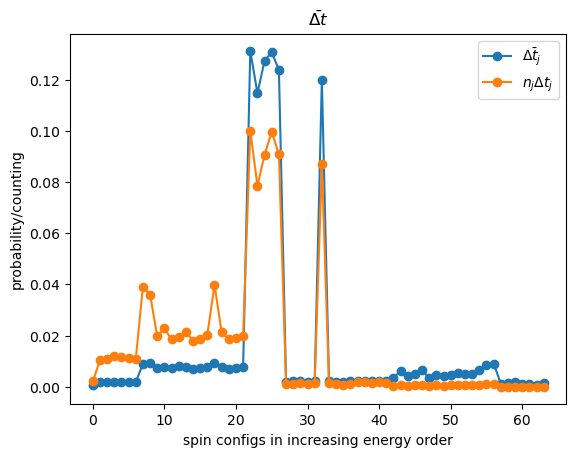

In [110]:
time_frac = []
for key in keys1:
    time_frac.append(np.mean([time_list[i] for i in indices2[key]]))

plt.plot( np.array(time_frac)[idx]/sum(time_frac), 'o-', label = r'$\bar{\Delta t_{j}}$')
plt.plot(np.array(time_frac1)[idx]/sum(time_frac1), 'o-', label = r'$ n_{j}\Delta t_{j}$')
plt.title(r'$\bar{\Delta t}$')
plt.xlabel('spin configs in increasing energy order')
plt.ylabel('probability/counting')
plt.legend()

print(np.mean(time_frac))

In [ ]:
print(in)

ValueError: x and y must be the same size

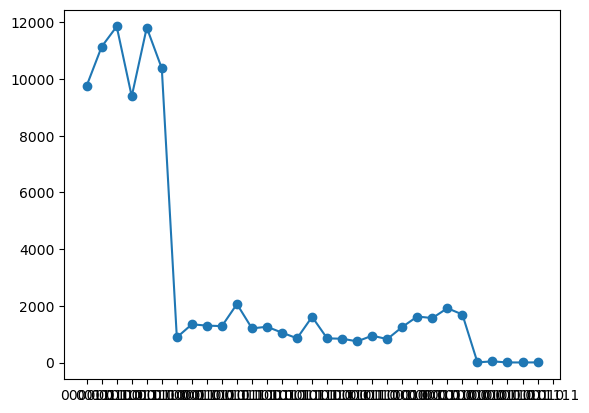

In [34]:
duration = len(spin_config2[3000:])
plt.plot(np.array(time_frac1)[idx],'-o', label = 'Fraction of time on each config')
plt.scatter(labels_sorted, P[idx], color='0.2', label='Theoretical Probability', zorder=5)
plt.plot(np.array(vals_by_key1)[idx]/duration,'o-',label = 'MC spin config counting')
plt.xlabel('Spin Configurations (sorted by energy)')
plt.ylabel('Probability')
plt.title(f'Spin Configuration Distribution H={H}, L={L}, steps={duration}, error rate={error_rate}')
plt.xticks(rotation=90)
plt.legend()
# plt.ylim(0, 0.1)